# Sanity check — EuroSAT para Lab 3 (fine-tuning)

Objetivo: verificar antes de reescribir el `.lab.md` que, con un subset de EuroSAT equivalente en volumen al dataset hotdog, se cumplen las dos condiciones:

1. **Tiempo de entrenamiento comparable al de hotdog** (pensado para Colab T4, validamos en M3 con MPS).
2. **Gap didáctico claro** entre fine-tune y from-scratch después de 5 épocas.

Config: EuroSAT RGB, 10 clases, 200 imágenes de train y 100 de test por clase (2000 / 1000 total — casi idéntico a hotdog).

In [1]:
import os, time, random
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, models
from torchvision.datasets import EuroSAT
import matplotlib.pyplot as plt

# Device: MPS (M3) > CUDA (Colab) > CPU
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Device: {device}')
print(f'Torch : {torch.__version__}')

Device: mps
Torch : 2.11.0


In [2]:
# Descarga + extracción (una sola vez). torchvision deja la data en data/eurosat/2750/
data_root = 'data'
os.makedirs(data_root, exist_ok=True)
_ = EuroSAT(root=data_root, download=True)
print('EuroSAT listo.')

EuroSAT listo.


In [3]:
# Transforms adaptados a satelital:
#  - Resize(224) directo: los tiles son 64x64; RandomResizedCrop recortaba textura de clase.
#  - RandomVerticalFlip: las imágenes cenitales no tienen "arriba", doblamos la diversidad gratis.
normalize = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    normalize,
])
test_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize,
])

# Dos ImageFolder sobre el mismo root, uno por transform
train_full = EuroSAT(root=data_root, transform=train_tf)
test_full  = EuroSAT(root=data_root, transform=test_tf)

# Split estratificado
TRAIN_PER_CLASS = 300
TEST_PER_CLASS  = 100

rng = random.Random(42)
class_to_indices = defaultdict(list)
for idx, (_, label) in enumerate(train_full.samples):
    class_to_indices[label].append(idx)

train_idx, test_idx = [], []
for cls, idxs in class_to_indices.items():
    rng.shuffle(idxs)
    train_idx.extend(idxs[:TRAIN_PER_CLASS])
    test_idx.extend(idxs[TRAIN_PER_CLASS:TRAIN_PER_CLASS + TEST_PER_CLASS])

train_ds = Subset(train_full, train_idx)
test_ds  = Subset(test_full,  test_idx)

print(f'Clases ({len(train_full.classes)}): {train_full.classes}')
print(f'Train: {len(train_ds)}  |  Test: {len(test_ds)}')


Clases (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Train: 3000  |  Test: 1000


In [4]:
BATCH_SIZE = 64
# num_workers=0 en MPS para evitar problemas de multiprocessing; en Colab se puede subir.
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [5]:
def train_model(net, train_loader, test_loader, epochs, lr,
                weight_decay=1e-3, param_groups=None, device=device):
    net.to(device)
    loss_fn = nn.CrossEntropyLoss()
    if param_groups is None:
        opt = torch.optim.SGD(net.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        opt = torch.optim.SGD(param_groups, momentum=0.9, weight_decay=weight_decay)

    hist = {'train_loss': [], 'train_acc': [], 'test_acc': [], 'epoch_time': []}
    for ep in range(epochs):
        t0 = time.time()
        net.train()
        loss_sum, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = net(x)
            loss = loss_fn(out, y)
            loss.backward()
            opt.step()
            loss_sum += loss.item() * x.size(0)
            correct  += (out.argmax(1) == y).sum().item()
            total    += x.size(0)
        tr_loss, tr_acc = loss_sum / total, correct / total

        net.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                out = net(x)
                correct += (out.argmax(1) == y).sum().item()
                total   += x.size(0)
        te_acc = correct / total
        dt = time.time() - t0

        hist['train_loss'].append(tr_loss)
        hist['train_acc'].append(tr_acc)
        hist['test_acc'].append(te_acc)
        hist['epoch_time'].append(dt)
        print(f'Ep {ep+1}/{epochs}  loss={tr_loss:.3f}  train_acc={tr_acc:.3f}  test_acc={te_acc:.3f}  ({dt:.1f}s)')
    return hist

In [6]:
# ─── Fine-tuning: ResNet-18 preentrenada, lr diferencial (backbone lr, fc 10*lr) ───
print('=== Fine-tuning (ResNet-18 preentrenada) ===')
torch.manual_seed(0)

finetune_net = models.resnet18(weights='DEFAULT')
finetune_net.fc = nn.Linear(finetune_net.fc.in_features, 10)
nn.init.xavier_uniform_(finetune_net.fc.weight)
nn.init.zeros_(finetune_net.fc.bias)

params_backbone = [p for n, p in finetune_net.named_parameters() if not n.startswith('fc')]
params_fc       = list(finetune_net.fc.parameters())
LR = 5e-3
param_groups = [
    {'params': params_backbone, 'lr': LR},
    {'params': params_fc,       'lr': LR * 10},
]

t0 = time.time()
hist_ft = train_model(finetune_net, train_loader, test_loader,
                      epochs=5, lr=LR, param_groups=param_groups)
print(f'Tiempo total fine-tune: {time.time()-t0:.1f}s')

=== Fine-tuning (ResNet-18 preentrenada) ===
Ep 1/5  loss=1.385  train_acc=0.716  test_acc=0.607  (12.0s)
Ep 2/5  loss=0.587  train_acc=0.863  test_acc=0.716  (11.4s)
Ep 3/5  loss=0.405  train_acc=0.898  test_acc=0.816  (11.1s)
Ep 4/5  loss=0.245  train_acc=0.928  test_acc=0.931  (11.1s)
Ep 5/5  loss=0.148  train_acc=0.951  test_acc=0.953  (11.4s)
Tiempo total fine-tune: 57.1s


In [7]:
# ─── From-scratch: ResNet-18 inicialización random, mismo bucle ───
print('=== From-scratch (ResNet-18 random init) ===')
torch.manual_seed(0)

scratch_net = models.resnet18(weights=None)
scratch_net.fc = nn.Linear(scratch_net.fc.in_features, 10)

t0 = time.time()
hist_sc = train_model(scratch_net, train_loader, test_loader,
                      epochs=5, lr=0.05)
print(f'Tiempo total scratch: {time.time()-t0:.1f}s')

=== From-scratch (ResNet-18 random init) ===
Ep 1/5  loss=2.260  train_acc=0.327  test_acc=0.356  (11.1s)
Ep 2/5  loss=1.562  train_acc=0.457  test_acc=0.381  (11.1s)
Ep 3/5  loss=1.412  train_acc=0.507  test_acc=0.447  (11.3s)
Ep 4/5  loss=1.197  train_acc=0.584  test_acc=0.552  (11.6s)
Ep 5/5  loss=1.092  train_acc=0.609  test_acc=0.637  (11.8s)
Tiempo total scratch: 56.9s


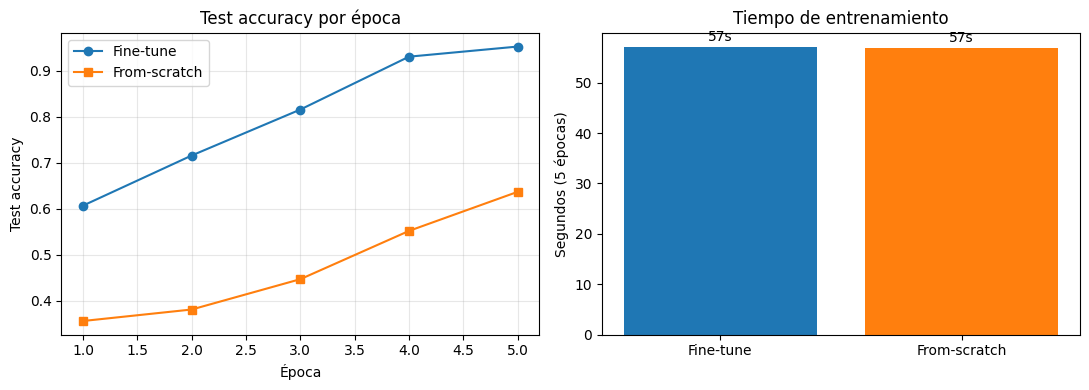

RESUMEN
Device:           mps
Train / Test:     3000 / 1000

Fine-tune final:  0.953
Scratch final:    0.637
Gap:              +0.316

Tiempo fine-tune: 57.0s
Tiempo scratch:   56.9s
Tiempo total:     113.9s


In [8]:
# ─── Comparación ───
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

epochs = range(1, len(hist_ft['test_acc']) + 1)
axes[0].plot(epochs, hist_ft['test_acc'], label='Fine-tune',   marker='o')
axes[0].plot(epochs, hist_sc['test_acc'], label='From-scratch', marker='s')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Test accuracy')
axes[0].set_title('Test accuracy por época')
axes[0].legend(); axes[0].grid(alpha=0.3)

tot_ft = sum(hist_ft['epoch_time'])
tot_sc = sum(hist_sc['epoch_time'])
axes[1].bar(['Fine-tune', 'From-scratch'], [tot_ft, tot_sc], color=['C0', 'C1'])
axes[1].set_ylabel('Segundos (5 épocas)')
axes[1].set_title('Tiempo de entrenamiento')
for i, v in enumerate([tot_ft, tot_sc]):
    axes[1].text(i, v + max(tot_ft, tot_sc) * 0.02, f'{v:.0f}s', ha='center')
plt.tight_layout()
plt.show()

print('=' * 50)
print('RESUMEN')
print('=' * 50)
print(f'Device:           {device}')
print(f'Train / Test:     {len(train_ds)} / {len(test_ds)}')
print()
print(f'Fine-tune final:  {hist_ft["test_acc"][-1]:.3f}')
print(f'Scratch final:    {hist_sc["test_acc"][-1]:.3f}')
print(f'Gap:              {hist_ft["test_acc"][-1] - hist_sc["test_acc"][-1]:+.3f}')
print()
print(f'Tiempo fine-tune: {tot_ft:.1f}s')
print(f'Tiempo scratch:   {tot_sc:.1f}s')
print(f'Tiempo total:     {tot_ft + tot_sc:.1f}s')

## Criterios de decisión

- **Tiempo total ≤ ~10 min en M3 (MPS)** → factible en Colab T4 (suele ser ~2× más rápido). Si supera esto en M3, reducir `TRAIN_PER_CLASS` o `BATCH_SIZE`.
- **Gap fine-tune − scratch ≥ 0.20** con from-scratch claramente por encima de 10% (azar) → el mensaje didáctico se ve. Si el gap es menor, subir épocas o bajar `TRAIN_PER_CLASS` para hacer la tarea más dependiente del preentrenamiento.
- **Fine-tune ≥ 0.85** en test → confirma que ImageNet transfiere razonablemente bien a satelital pese al upsample 64→224.